In [1]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 23.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<

In [19]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)


In [10]:
# obtener desde GitHub
red = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-red%5B1%5D.csv"
white = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/main/datasets/Wine_Quality/winequality-white%5B1%5D.csv"

# Cargar los datos
df_red = pd.read_csv(red, sep=';')
df_white = pd.read_csv(white, sep=';')

# Combinar ambos datasets
df = pd.concat([df_red, df_white], ignore_index=True)

# Mostrar las primeras filas
print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [11]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana

df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)

#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [12]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30


In [17]:
# Definir los modelos
models=[LogisticRegression(max_iter = 1000,  random_state=42),
        DecisionTreeClassifier(max_depth=7,min_samples_split=10,min_samples_leaf=2,random_state=42),
       RandomForestClassifier(n_estimators=250,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42),
        LGBMClassifier(n_estimators=300,learning_rate=0.1,max_depth=15,num_leaves=50,subsample=0.8,colsample_bytree=0.8,random_state=42),
        CatBoostClassifier(iterations=100,learning_rate=0.1,depth=6,verbose=0,random_state=42),
        XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss',random_state=42),
        GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,random_state=42),
        AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=0.5,random_state=42),
        BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,max_features=0.6,max_samples=0.8,bootstrap=True,random_state=42),
         KNeighborsClassifier()]

# Crear una lista de nombres de modelos
names =['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'LightGBM Classifier', 'Catboost Classifier', 'XGBoost Classifier',
        'Gradient Boosting Classifier','AdaBoost Classifier','Bagging Classifier','KNN Classifier']


# Crear listas vacías para la precisión y desviación estándar
accuracy = []
std = []

# Realizar validación cruzada
for model in models:
    cv = KFold(n_splits=10, shuffle=True, random_state=1)
    n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=1, error_score='raise')
    mean_score = np.mean(n_scores)
    std_score = np.std(n_scores)
    accuracy.append(mean_score)
    std.append(std_score)

# DataFrame con resultados
score_df = pd.DataFrame({
    'Model': names,
    'Accuracy': accuracy,
    'Std': std
})

# Mostrar resultados
score_df_sorted = score_df.sort_values(by='Accuracy', ascending=False)
print(score_df_sorted)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1160, number of negative: 4687
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 5847, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198392 -> initscore=-1.396373
[LightGBM] [Info] Start training from score -1.396373
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

**Stacking**

In [20]:
# Base learners
estimators = [
    ('lgbm', LGBMClassifier(n_estimators=300,learning_rate=0.1,max_depth=15,num_leaves=50,subsample=0.8,colsample_bytree=0.8,random_state=42,verbose=0)),
    ('bag', BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,max_features=0.6,max_samples=0.8,bootstrap=True,random_state=42,verbose=0)),
    ('rf', RandomForestClassifier(n_estimators=250,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,verbose=0)),
    ('xgb', XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss',random_state=42,verbose=0)),
]

# Meta learner
meta_model = LogisticRegression(max_iter = 1000,  random_state=42)

# Stacking
stack_model = StackingClassifier(estimators=estimators, final_estimator=meta_model, cv=5)

# Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
stack_model.fit(X_train, y_train)

# Evaluación
y_pred = stack_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred))


# Validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
stack_scores = cross_val_score(stack_model, X, y, cv=cv, scoring="accuracy")

print("Resultados de Validación Cruzada del Ensemble Stacking:")
print(f"Accuracy por fold: {np.round(stack_scores, 3)}")
print(f"Promedio: {stack_scores.mean():.3f} | STD: {stack_scores.std():.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1023, number of negative: 4174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1451
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196844 -> initscore=-1.406135
[LightGBM] [Info] Start training from score -1.406135
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 818, number

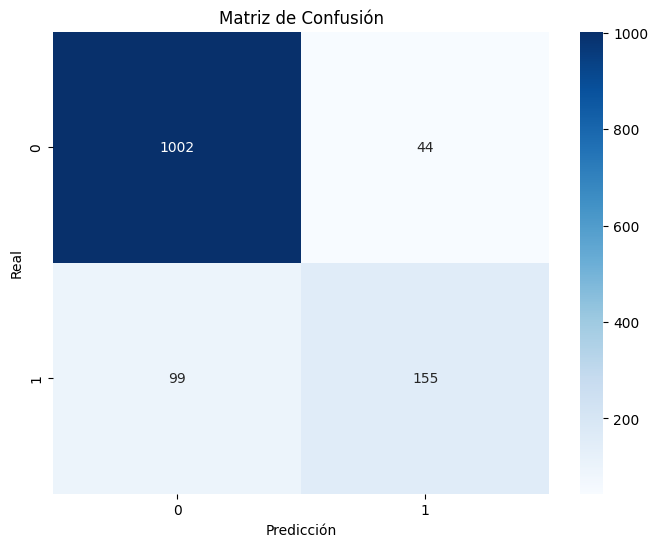

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1046
           1       0.78      0.61      0.68       254

    accuracy                           0.89      1300
   macro avg       0.84      0.78      0.81      1300
weighted avg       0.88      0.89      0.88      1300



In [21]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = stack_model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


Voting

In [22]:
# Hard Voting
voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_hard.fit(X_train, y_train)
hard_pred = voting_hard.predict(X_test)
print(f"Hard Voting Accuracy: {accuracy_score(y_test, hard_pred):.3f}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1023, number of negative: 4174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1451
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196844 -> initscore=-1.406135
[LightGBM] [Info] Start training from score -1.406135
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Hard Voting Accuracy: 0.877


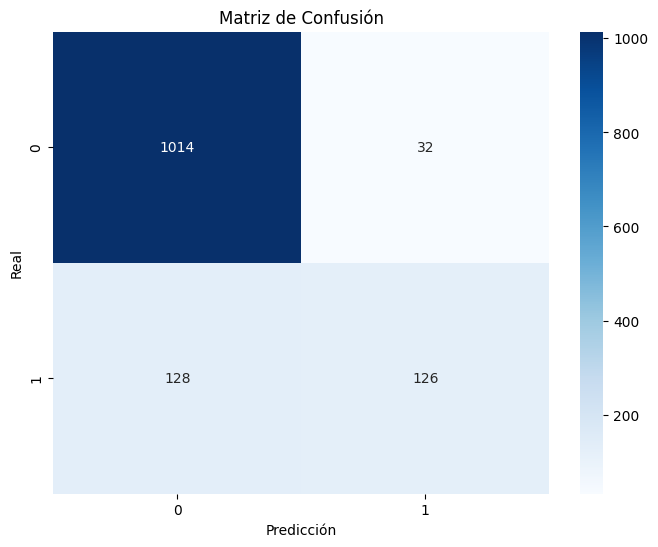

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1046
           1       0.80      0.50      0.61       254

    accuracy                           0.88      1300
   macro avg       0.84      0.73      0.77      1300
weighted avg       0.87      0.88      0.87      1300



In [24]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, hard_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, hard_pred))


In [25]:
# Soft Voting
voting_soft = VotingClassifier(estimators=estimators, voting='soft')
voting_soft.fit(X_train, y_train)
soft_pred = voting_soft.predict(X_test)
print(f"Soft Voting Accuracy: {accuracy_score(y_test, soft_pred):.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1023, number of negative: 4174
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1451
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196844 -> initscore=-1.406135
[LightGBM] [Info] Start training from score -1.406135
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Soft Voting Accuracy: 0.889


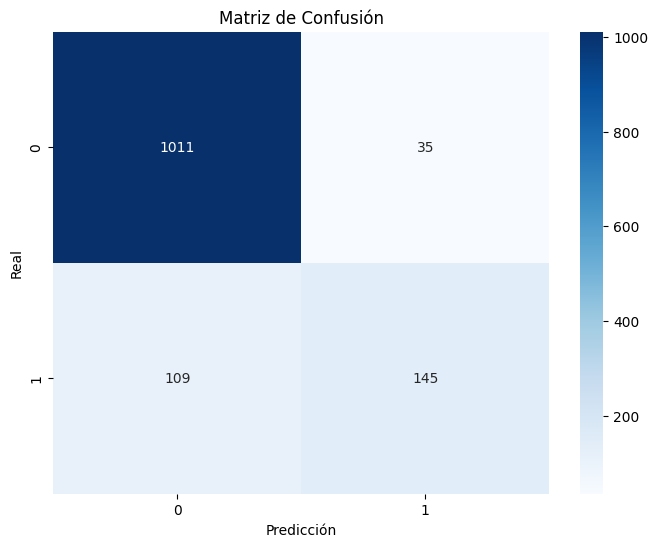

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1046
           1       0.81      0.57      0.67       254

    accuracy                           0.89      1300
   macro avg       0.85      0.77      0.80      1300
weighted avg       0.88      0.89      0.88      1300



In [26]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, soft_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, soft_pred))

#curva ROC
y_probs = voting_soft.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

In [32]:
# Weighted Voting (soft + pesos)
weights = [1, 0.5, 0.5, 0.5]  # ajustar según desempeño individual
voting_weighted = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
voting_weighted.fit(X_train, y_train)
weighted_pred = voting_weighted.predict(X_test)
print(f"Weighted Voting Accuracy: {accuracy_score(y_test, weighted_pred):.3f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1023, number of negative: 4174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1451
[LightGBM] [Info] Number of data points in the train set: 5197, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.196844 -> initscore=-1.406135
[LightGBM] [Info] Start training from score -1.406135
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Weighted Voting Accuracy: 0.887


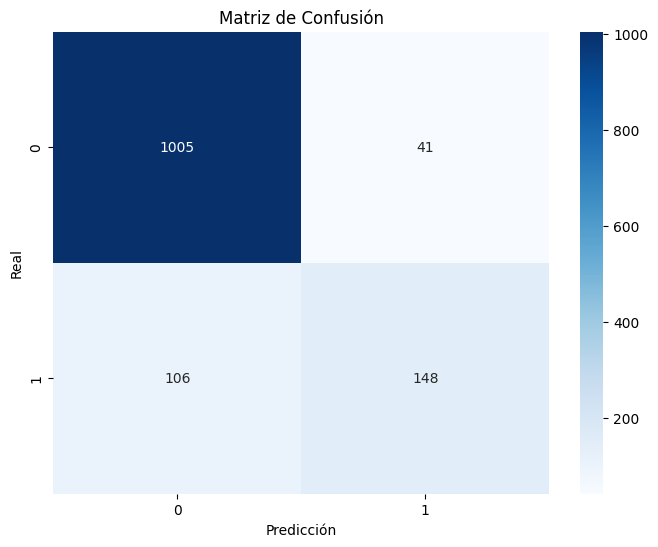

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1046
           1       0.78      0.58      0.67       254

    accuracy                           0.89      1300
   macro avg       0.84      0.77      0.80      1300
weighted avg       0.88      0.89      0.88      1300



In [33]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, weighted_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, weighted_pred))

#curva ROC
y_probs = voting_weighted.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Aplicación en test de seasonal vaccine

In [36]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())

   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [37]:
# Cargar dataset limpio
X = flu_codificado.drop(columns='seasonal_vaccine')
y = flu_codificado['seasonal_vaccine']

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)


In [40]:
# Definir los modelos (10min)
models=[LogisticRegression(max_iter = 1000,  random_state=42),
        DecisionTreeClassifier(max_depth=7,min_samples_split=10,min_samples_leaf=2,random_state=42),
       RandomForestClassifier(n_estimators=250,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,verbose=0),
        LGBMClassifier(n_estimators=300,learning_rate=0.1,max_depth=1,num_leaves=31,subsample=0.8,colsample_bytree=0.8,random_state=42,verbose=0),
        CatBoostClassifier(iterations=100,learning_rate=0.05,depth=8,verbose=0,l2_leaf_reg=3,random_state=42),
        XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss',random_state=42,verbose=0),
        GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,random_state=42,verbose=0),
        AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=100,learning_rate=0.5,random_state=42),
        BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=200,max_features=0.6,max_samples=0.8,bootstrap=True,random_state=42,verbose=0),
         KNeighborsClassifier()]

# Crear una lista de nombres de modelos
names =['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier', 'LightGBM Classifier', 'Catboost Classifier', 'XGBoost Classifier',
        'Gradient Boosting Classifier','AdaBoost Classifier','Bagging Classifier','KNN Classifier']


# Crear listas vacías para la precisión y desviación estándar
accuracy = []
std = []

# Realizar validación cruzada
for model in models:
    cv = KFold(n_splits=10, shuffle=True, random_state=1)
    n_scores = cross_val_score(model, X, y, scoring='accuracy', cv=cv, n_jobs=1, error_score='raise')
    mean_score = np.mean(n_scores)
    std_score = np.std(n_scores)
    accuracy.append(mean_score)
    std.append(std_score)

# DataFrame con resultados
score_df = pd.DataFrame({
    'Model': names,
    'Accuracy': accuracy,
    'Std': std
})

# Mostrar resultados
score_df_sorted = score_df.sort_values(by='Accuracy', ascending=False)
print(score_df_sorted)


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [41]:
# Base learners
estimators = [
    ('gb', GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,random_state=42,verbose=0)),
    ('xgb', XGBClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,subsample=0.8,colsample_bytree=0.8,use_label_encoder=False,eval_metric='logloss',random_state=42,verbose=0)),
    ('cat', CatBoostClassifier(iterations=100,learning_rate=0.05,depth=8,verbose=0,l2_leaf_reg=3,random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=250,max_depth=20,min_samples_split=5,min_samples_leaf=2,max_features='sqrt',random_state=42,verbose=0)),
]

# Meta learner
meta_model = LogisticRegression(max_iter = 1000,  random_state=42)

# Stacking
stack_model = StackingClassifier(estimators=estimators, final_estimator=meta_model, cv=5)

# Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
stack_model.fit(X_train, y_train)

# Evaluación
y_pred = stack_model.predict(X_test)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred))


# Validación cruzada
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
stack_scores = cross_val_score(stack_model, X, y, cv=cv, scoring="accuracy")

print("Resultados de Validación Cruzada del Ensemble Stacking:")
print(f"Accuracy por fold: {np.round(stack_scores, 3)}")
print(f"Promedio: {stack_scores.mean():.3f} | STD: {stack_scores.std():.3f}")

Stacking Accuracy: 0.7791089479595658
Resultados de Validación Cruzada del Ensemble Stacking:
Accuracy por fold: [0.791 0.774 0.788 0.772 0.802 0.784 0.77  0.781 0.785 0.784]
Promedio: 0.783 | STD: 0.009


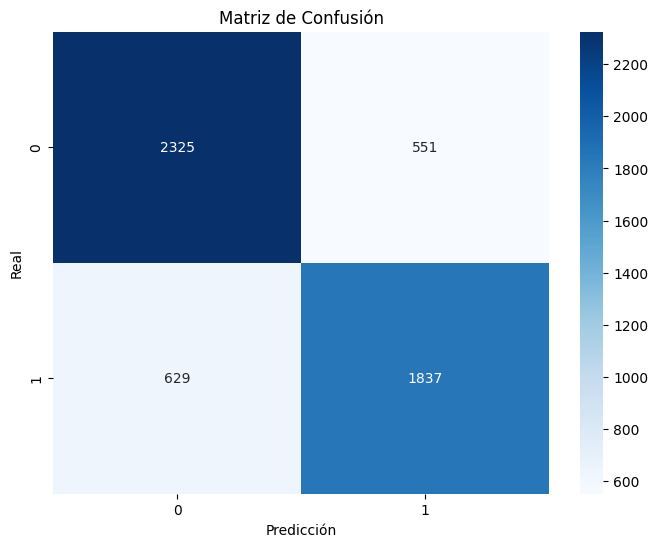

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2876
           1       0.77      0.74      0.76      2466

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [42]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

#curva ROC
y_probs = stack_model.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


In [43]:
# Hard Voting
voting_hard = VotingClassifier(estimators=estimators, voting='hard')
voting_hard.fit(X_train, y_train)
hard_pred = voting_hard.predict(X_test)
print(f"Hard Voting Accuracy: {accuracy_score(y_test, hard_pred):.3f}")


Hard Voting Accuracy: 0.779


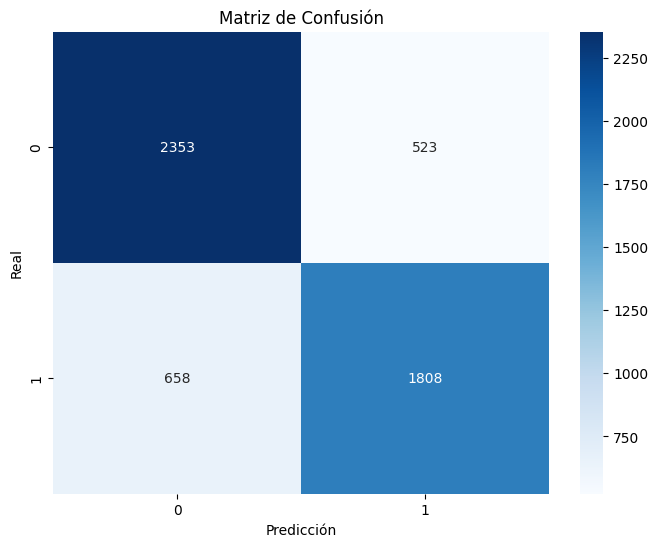

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2876
           1       0.78      0.73      0.75      2466

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [44]:
#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, hard_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, hard_pred))

Soft Voting Accuracy: 0.779


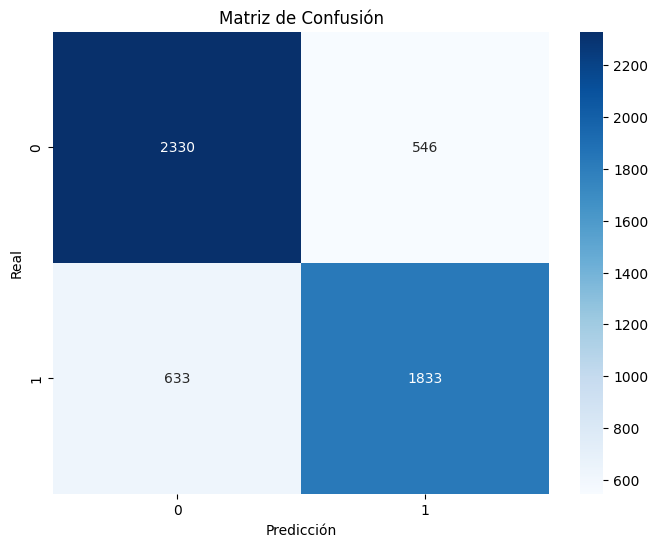

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2876
           1       0.77      0.74      0.76      2466

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [45]:
# Soft Voting
voting_soft = VotingClassifier(estimators=estimators, voting='soft')
voting_soft.fit(X_train, y_train)
soft_pred = voting_soft.predict(X_test)
print(f"Soft Voting Accuracy: {accuracy_score(y_test, soft_pred):.3f}")

#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, soft_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, soft_pred))

#curva ROC
y_probs = voting_soft.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Weighted Voting Accuracy: 0.780


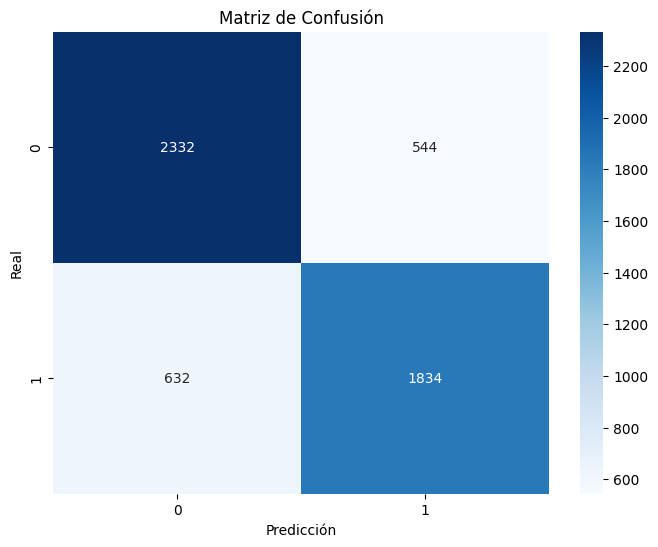

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80      2876
           1       0.77      0.74      0.76      2466

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [50]:
# Weighted Voting (soft + pesos)
weights = [1, 0.5, 0.5, 0.5]  # ajustar según desempeño individual
voting_weighted = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
voting_weighted.fit(X_train, y_train)
weighted_pred = voting_weighted.predict(X_test)
print(f"Weighted Voting Accuracy: {accuracy_score(y_test, weighted_pred):.3f}")

#Matriz de Correlacion
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, weighted_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

#Reporte de Clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, weighted_pred))

#curva ROC
y_probs = voting_weighted.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Creacion archivo probabilidades

In [47]:
voting_weighted.fit(X_train, y_train)

flu_test = flu_test.drop(columns=['predicted_score'], errors='ignore')


assert set(X_train.columns).issubset(flu_test.columns), "flu_test debe contener las mismas variables que X_train"

# Obtener las probabilidades de la clase positiva
probs = voting_weighted.predict_proba(flu_test[X_train.columns])[:, 1]

# Agregar la columna de score redondeado
flu_test = flu_test.copy()
flu_test['predicted_score'] = probs.round(3)

# Seleccionar columnas relevantes
pred_flu = flu_test[['respondent_id', 'predicted_score']].sort_values(by='predicted_score', ascending=False)

# Generar nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"essemble_output_{timestamp}.csv"

# Exportar a CSV
pred_flu.to_csv(file_name, index=False)

# Mostrar resultados
display(pred_flu)

,respondent_id,predicted_score
4741,31448,0.970
5424,32131,0.967
17926,44633,0.966
1707,28414,0.964
19718,46425,0.963
...,...,...
5129,31836,0.024
17904,44611,0.023
17481,44188,0.022
26401,53108,0.021
